In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from backtest_functions import simulate_kelly
from backtest_plots import plot_bankroll_distributions, plot_backtest 

In [ ]:
# https://vegapit.com/article/numerically_solve_kelly_criterion_multiple_simultaneous_bets/
# https://nickyoder.com/kelly-criterion/
# https://www.mma-ai.net/ 

# https://business.columbia.edu/sites/default/files-efs/pubfiles/6343/bayes_kelly.pdf
## Portfolio Choice and the Bayesian Kelly Criterion


c:\Users\jcmar\my_files\SportsBetting\BettingStrategy\KellyStrategy\betting_backtest\backtest_functions.py:460: RuntimeWarning: Mean of empty slice.
  vegas_acc_choice = np.where(np.array(group_stats['choice_decimal_odds'])[choice_idxs] < 2, 1, 0).mean()
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


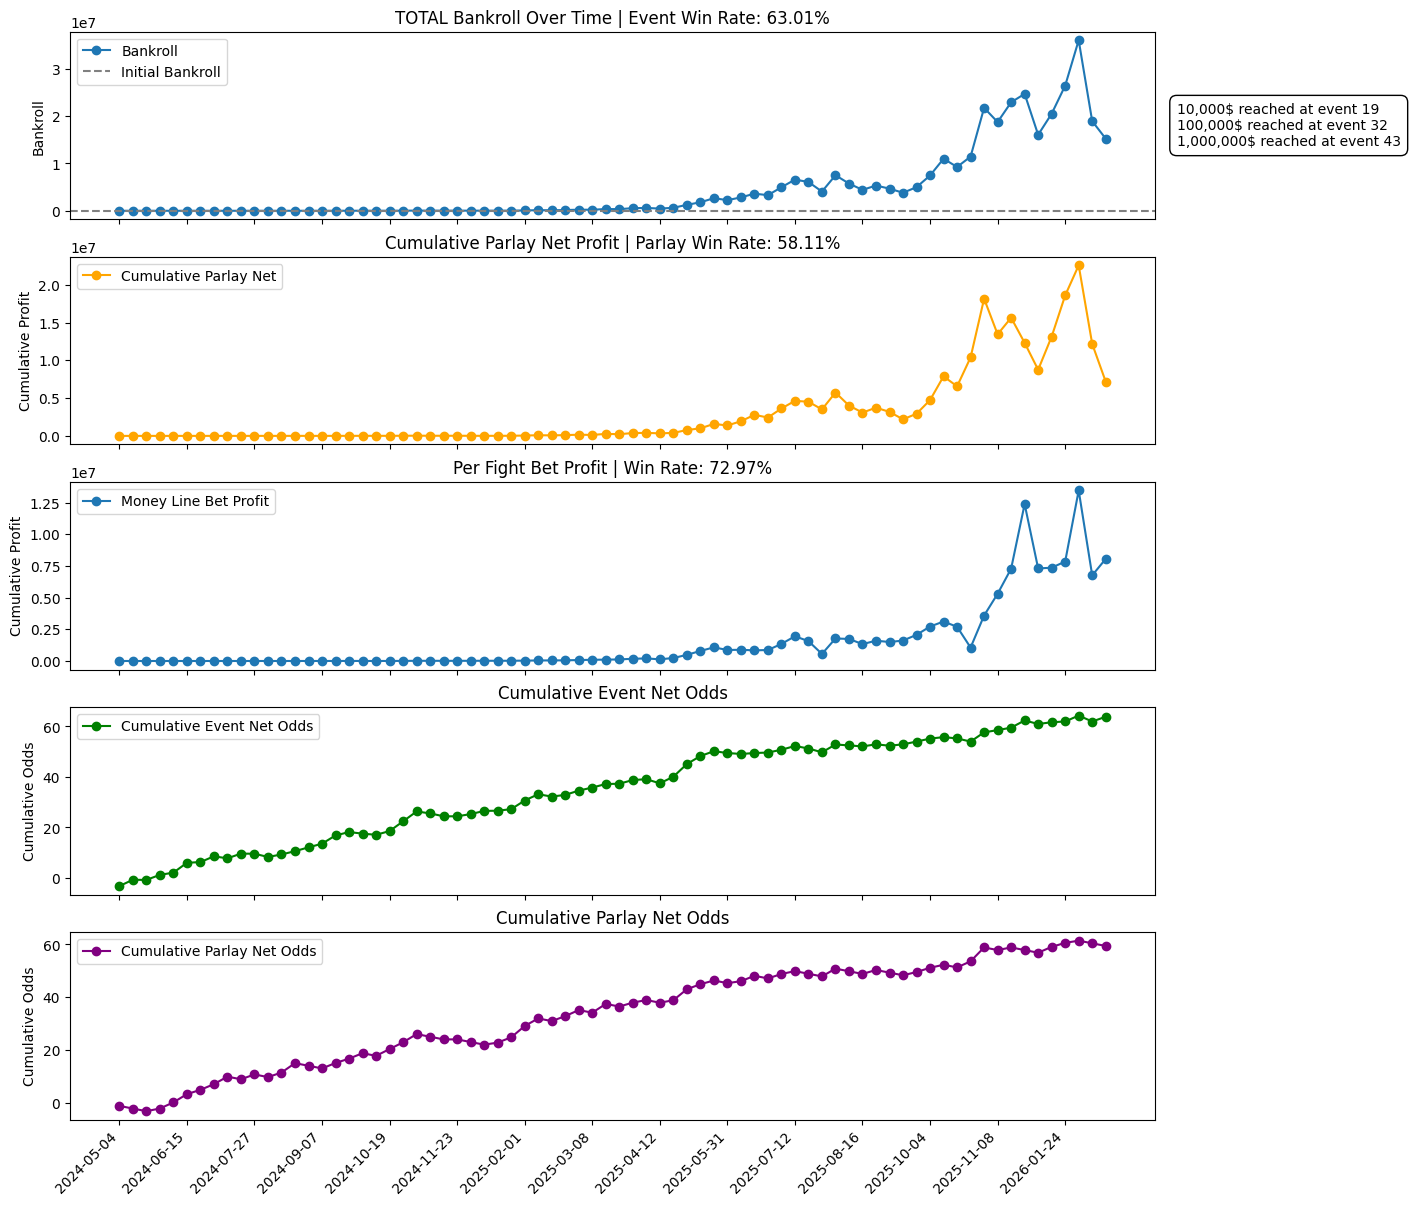

In [77]:
df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red']  # your decimal odds columns
real_decimal_odds = ['dec_open_blue', 'dec_open_red']

df_kelly, df_parlay = simulate_kelly(
    df_test_open,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,  
    max_drawdown=.25,
    N=2000,
    calc_parlay=True
)

# plot_bankroll_distributions(df_kelly, df_parlay)
plot_backtest(df_kelly, 500)
# plot_event_odds_stats(df_kelly)

# x_vars = ['mu_portfolio', 'sharpe_portfolio', 'portfolio_sigma']
# y_var = 'event_net_odds'
# kelly_analysis(df_kelly, x_vars, y_var)

df_kelly.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_open.csv')
df_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_open.csv')

In [ ]:
df_test_close = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close1.csv')

prob_cols = ['proba_blue', 'proba_red']
# fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red']
fair_decimal_odds = ['dec_fair_close1_blue', 'dec_fair_close1_red']  # your decimal odds columns
real_decimal_odds = ['dec_close1_blue', 'dec_close1_red']
df_kelly1, df_kelly1_parlay = simulate_kelly(
    None,
    df_test_close,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.25,
    N=1000,
    kelly_pred_history=False,
    calc_parlay=True,
    fighter_history=False,
    test_nn=False
)

plot_backtest(df_kelly1, 500)


df_kelly1.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close1.csv')
df_kelly1.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\kelly_close1.csv')
df_kelly1_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_close1.csv')

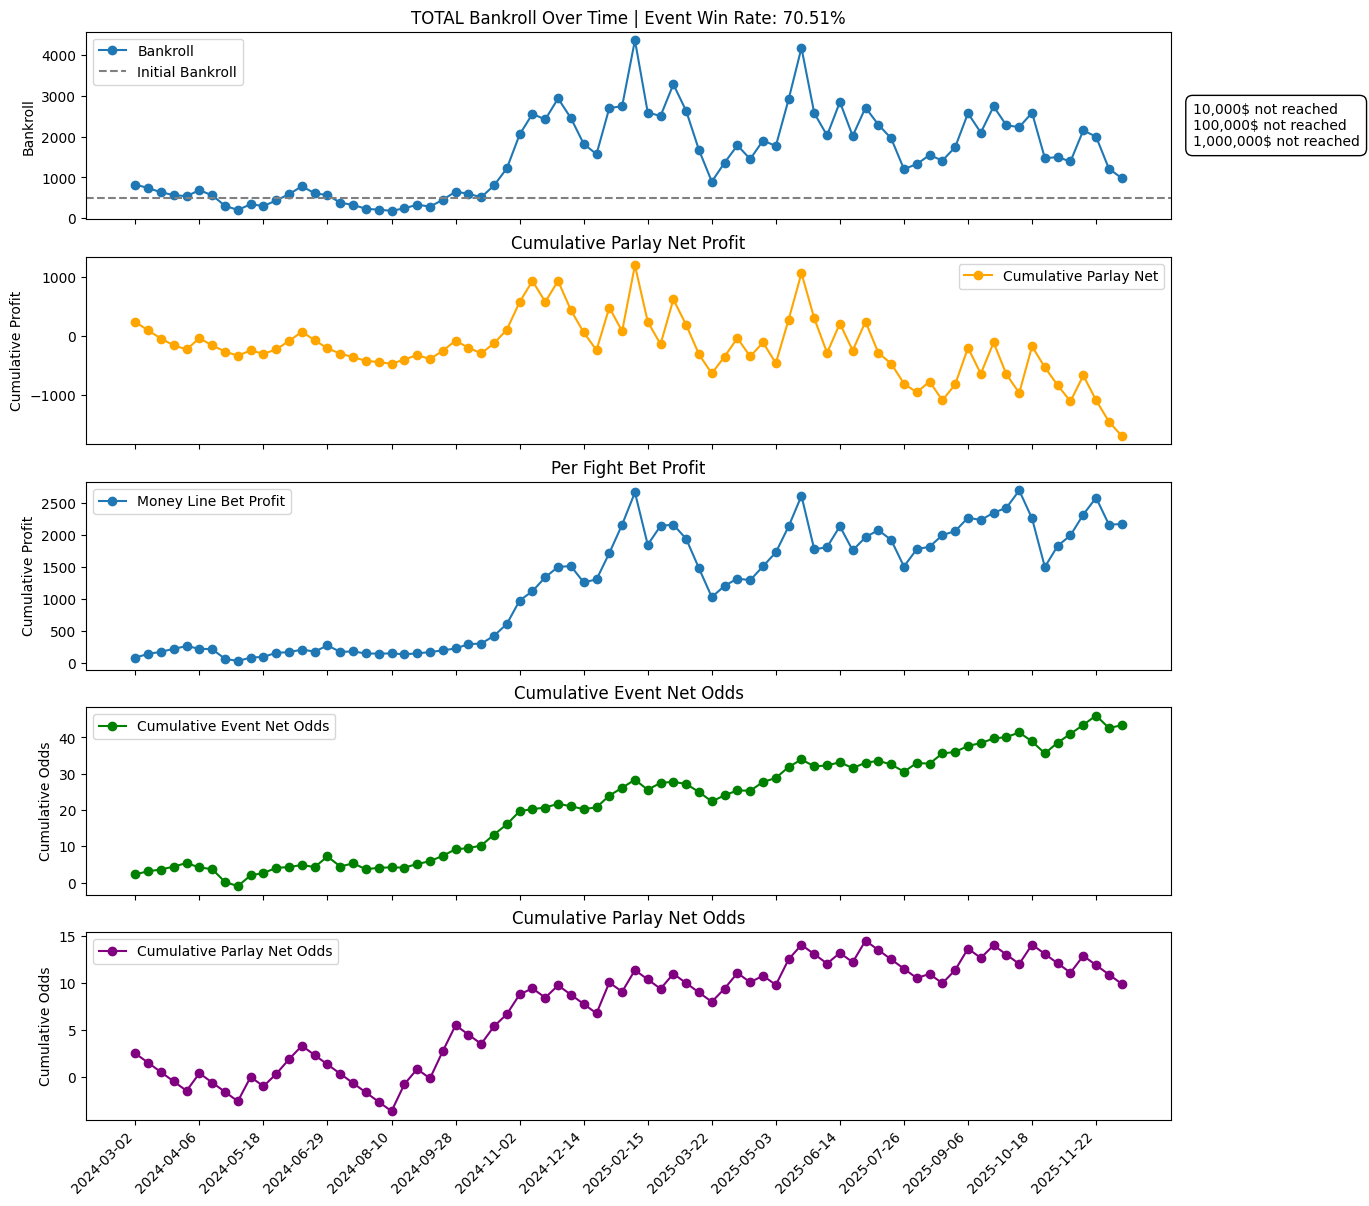

In [19]:
df_test_close = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close2.csv')


prob_cols = ['proba_blue', 'proba_red']
# fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red']
fair_decimal_odds = ['dec_fair_close2_blue', 'dec_fair_close2_red']  # your decimal odds columns
real_decimal_odds = ['dec_close2_blue', 'dec_close2_red']
df_kelly2, df_kelly2_parlay = simulate_kelly(
    None,
    df_test_close,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.25,
    N=1000,
    kelly_pred_history=False,
    calc_parlay=True,
    fighter_history=False,
    test_nn=False
)

plot_backtest(df_kelly2, 500)

df_kelly2.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close2.csv')
df_kelly2.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\kelly_close2.csv')
df_kelly2_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_close2.csv')

In [64]:
from backtest_plots import event_analysis, plot_event_odds_stats, correlate_with_vegas, summary_stats, pmf_plot
import pandas as pd 
import numpy as np

In [10]:
df_kelly = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_open.csv')
df_parlay = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_open.csv')


In [7]:
import matplotlib.pyplot as plt

In [87]:
df_kelly[df_kelly['vegas_acc_choice'].isna()][['choice_decimal_odds', 'date']]

,choice_decimal_odds,date
218,1.182149,2024-11-23
219,1.384615,2024-11-23
220,1.377358,2024-11-23


In [88]:
df_kelly[df_kelly['date']=='2024-11-23']

,fight_payout,choice_fstar,net_odds,choice_ev,choice_juice,choice_decimal_odds,parlay_net,parlay_net_odds,bankroll_pct_change,bankroll_postevent,...,juice_open_red,juice_open_blue,juice_close1_red,juice_close1_blue,juice_close2_red,juice_close2_blue,close1_red,close1_blue,close2_red,close2_blue
218,0.0,0.000000,0.0,-0.084884,0.021751,1.182149,0.0,0.0,0.0,29306.788277,...,0.021751,0.046388,0.013749,0.038199,0.010873,0.029024,-1000.0,600.0,-950.0,640.0
219,0.0,0.000000,0.0,-0.063068,0.024022,1.384615,0.0,0.0,0.0,29306.788277,...,0.024022,0.036038,0.034544,0.058151,0.006086,0.009358,-335.0,210.0,-270.0,250.0
220,0.0,0.007552,0.0,-0.026431,0.021420,1.377358,0.0,0.0,0.0,29306.788277,...,0.032476,0.021420,0.043567,0.026979,0.012165,0.007980,215.0,-305.0,240.0,-265.0


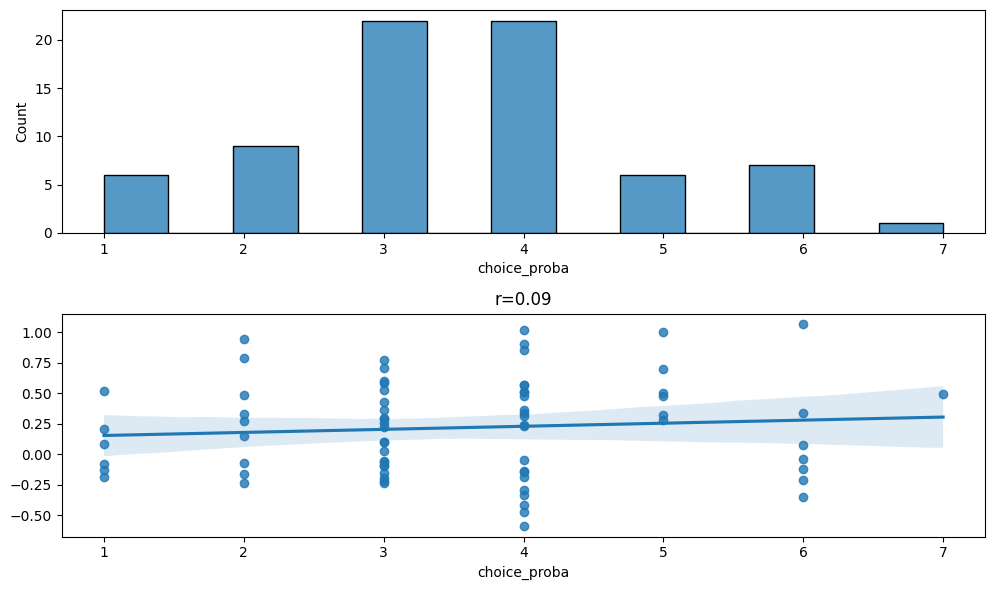

In [78]:
pmf_plot(df_kelly)

In [83]:
df_kelly['vegas_acc_choice'].isna().sum()

np.int64(3)

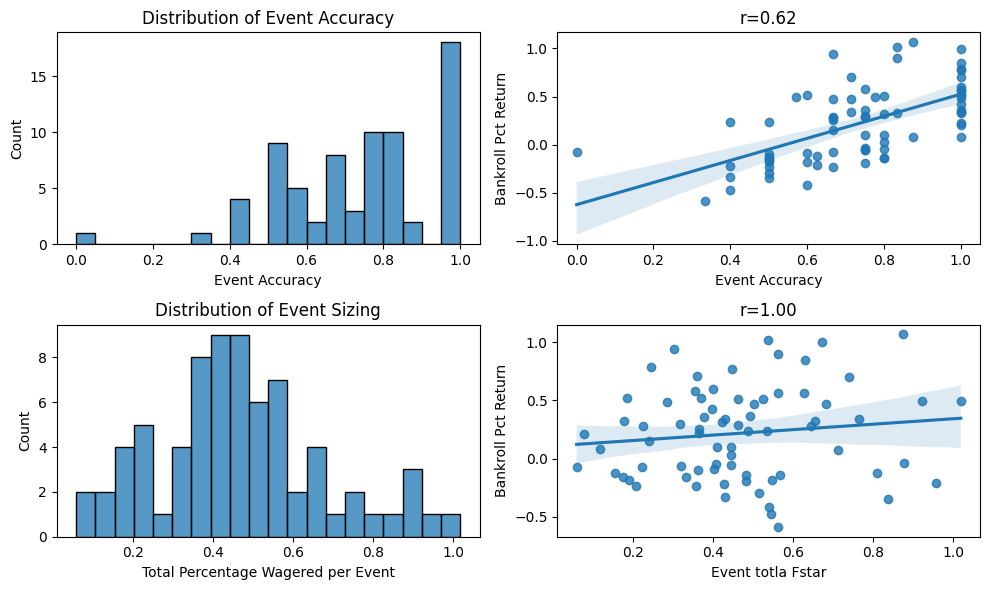

In [79]:
summary_stats(df_kelly)

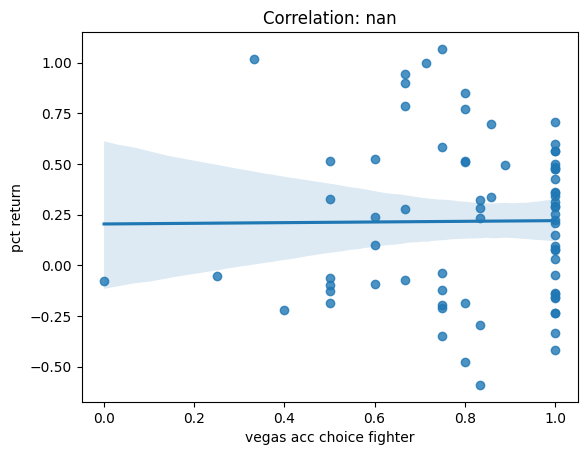

In [80]:
correlate_with_vegas(df_kelly)

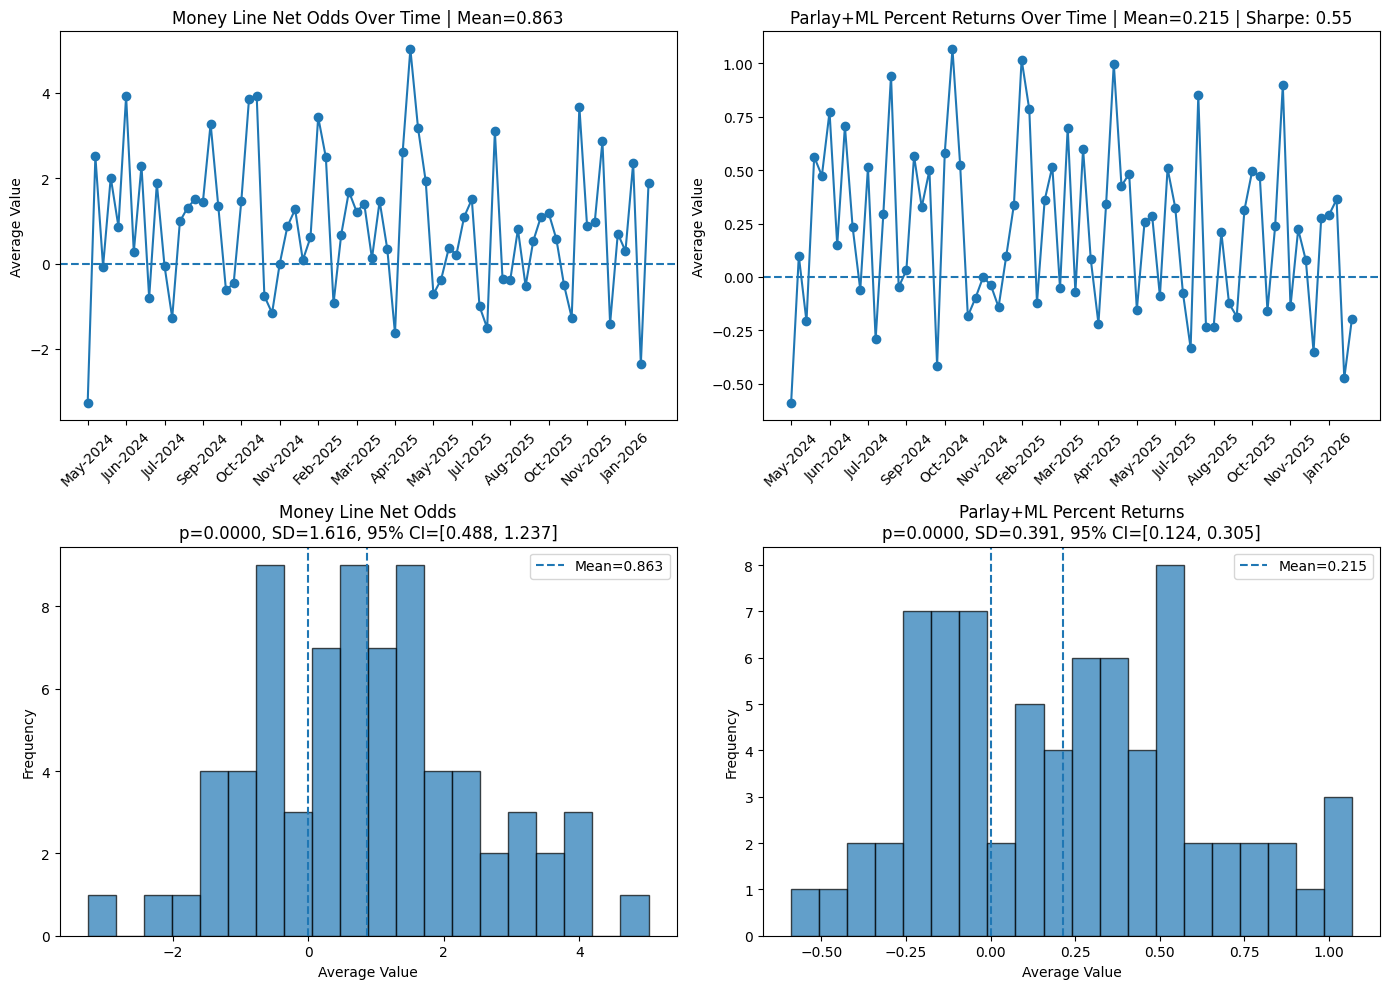

In [81]:
plot_event_odds_stats(df_kelly)

In [4]:
df_losses = df_kelly.sort_values(by='event_payout_per_fight')

In [5]:
df_losses[['choice_ev', 'event_bankroll_pct', 'fight_payout', 'event_payout_per_fight', 'bankroll_postevent', 'bankroll_pct_change', 'parlay_net_odds', 'parlay_net']]

,choice_ev,event_bankroll_pct,fight_payout,event_payout_per_fight,bankroll_postevent,bankroll_pct_change,parlay_net_odds,parlay_net
444,-0.106779,-0.065763,0.000000,-106343.711024,261809.120635,-0.409913,-1.000000,-75526.139348
445,0.081114,-0.065763,-41279.992696,-106343.711024,261809.120635,-0.409913,-1.000000,-75526.139348
442,-0.121013,-0.065763,0.000000,-106343.711024,261809.120635,-0.409913,-1.000000,-75526.139348
441,0.010383,-0.065763,-52124.365093,-106343.711024,261809.120635,-0.409913,-1.000000,-75526.139348
440,-0.026093,-0.065763,0.000000,-106343.711024,261809.120635,-0.409913,-1.000000,-75526.139348
...,...,...,...,...,...,...,...,...
454,0.062376,0.262448,13710.637634,68711.153573,445533.112319,0.701748,2.942683,115012.838111
448,-0.050361,0.262448,0.000000,68711.153573,445533.112319,0.701748,2.942683,115012.838111
447,0.050822,0.262448,7777.950805,68711.153573,445533.112319,0.701748,2.942683,115012.838111
451,0.354793,0.262448,23109.316028,68711.153573,445533.112319,0.701748,2.942683,115012.838111


In [8]:
pct_positive = (
    df_kelly.groupby('date')['parlay_net_odds']
      .first()
      .gt(0)
      .mean()
)

pct_positive

np.float64(0.5)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 72 and the array at index 1 has size 74

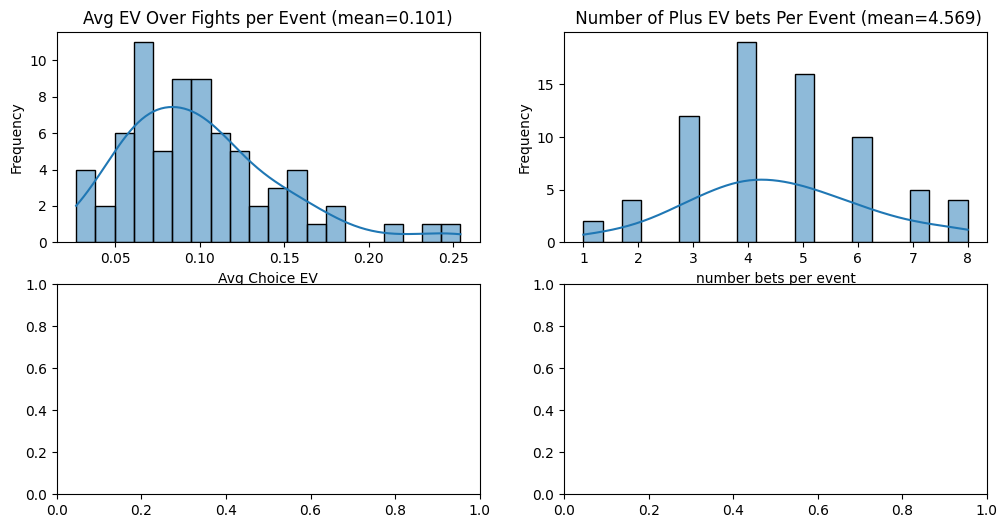

In [9]:
event_analysis(df_kelly)

https://wayback.archive-it.org/5456/20240920160238/https://www.eecs.harvard.edu/cs286r/courses/fall12/papers/Thorpe_KellyCriterion2007.pdf

https://medium.com/raposa-technologies/how-to-use-python-and-the-kelly-criterion-to-optimize-your-stock-portfolio-bb6e43df50c2



In [ ]:
https://web3.arxiv.org/abs/2207.14124?utm_source=chatgpt.com

https://pubmed.ncbi.nlm.nih.gov/35205582/

https://summit.sfu.ca/item/34958?utm_source=chatgpt.com


https://www.glicko.net/glicko/glicko2.pdf

https://www.glicko.net/glicko.html

https://ojs.aaai.org/index.php/AIIDE/article/view/5233


https://arxiv.org/abs/2303.16741?utm_source=chatgpt.com

https://opisthokonta.net/?cat=48


https://dashee87.github.io/football/python/predicting-football-results-with-statistical-modelling-dixon-coles-and-time-weighting/

